In [1]:
import os, calendar, re

import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
import matplotlib.colors as colors

from shapely.validation import make_valid

from adjustText import adjust_text

from datetime import datetime, timedelta

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"] = ["Montserrat", "DejaVu Sans"]

# --- Configuration ---
path_to_scenarios = '/home/abhis/india_power/scenarios'
path_to_images = '/home/gterren/india_power/images/'
path_to_csvs = '/home/abhis/india_power/gridpath_india_viz/csvs'
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
path_to_input = '/home/gterren/india_power/input_data/'

scenario = 'ra-8_prm_90_ccap'

tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + f'/{scenario}.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-5].split('_')[-1]
                df_['H'] = dirpath.split('/')[-4].split('_')[-1]
                df_['A'] = dirpath.split('/')[-3].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_1
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_2
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_3
pier_8_prm_90_ccap_2040_4
pier_8_prm_90_ccap_2040_4
pier_8_prm_9

    timepoint          load_zone   static_load  net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  18479.474483 -4184.234058             0.0   
1  2040040101  Arunachal_Pradesh    329.816680   261.025418             0.0   
2  2040040101              Assam   4089.792284  2142.845383             0.0   
3  2040040101             Bhutan      0.000000 -3091.070229             0.0   
4  2040040101              Bihar   9839.340580  5912.977812             0.0   

   unserved_energy  W  H  A  
0              0.0  1  1  9  
1              0.0  1  1  9  
2              0.0  1  1  9  
3              0.0  1  1  9  
4              0.0  1  1  9  


# State-level metrics for all iterations (includes national metrics)

In [3]:
df = df_load_.copy()

# Exclude Bhutan
df = df[df['load_zone'] != "Bhutan"].copy()

HOURS_PER_YEAR = 8760.0  
tau = 1.0  # 1 MW threshold for LOL event

df['is_lol']     = df['unserved_energy'] > tau
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

def compute_metrics(sub, label):
    """Compute RA metrics for a given dataframe slice."""
    num_iters = sub[['W','H','A']].drop_duplicates().shape[0]
    hrs_run_total = float(sub['hrs_in_tmp'].sum())
    n_years = hrs_run_total / HOURS_PER_YEAR if hrs_run_total else np.nan

    total_lol_hours    = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())

    days_with_lol = int(
        sub.groupby(['W','H','A','date'])['is_lol'].max().sum()
    )

    # Annualized metrics
    EUE_MWh_per_yr   = (total_unserved_MWh / n_years) if np.isfinite(n_years) else np.nan
    LOLH_hrs_per_yr  = (total_lol_hours / n_years) if np.isfinite(n_years) else np.nan
    LOLE_days_per_yr = (days_with_lol / n_years) if np.isfinite(n_years) else np.nan

    return {
        'load_zone':               label,
        'iterations (W,H,A)':      num_iters,
        'LOLH (hrs/yr)':           LOLH_hrs_per_yr,
        'EUE (MWh/yr)':            EUE_MWh_per_yr,
        'LOLE (days/yr)':          LOLE_days_per_yr,
        'LOLE (days/10yr)':        (LOLE_days_per_yr * 10) if np.isfinite(LOLE_days_per_yr) else np.nan,
        'LOLP (fraction of hrs)':  (total_lol_hours / hrs_run_total) if hrs_run_total > 0 else np.nan,
        'LOLP (%)':                ((total_lol_hours / hrs_run_total) * 100) if hrs_run_total > 0 else np.nan,
        'Annual Energy (MWh/yr)':  (total_energy_MWh / n_years) if np.isfinite(n_years) else np.nan,
        'NENS (%)':                (100 * EUE_MWh_per_yr / (total_energy_MWh / n_years))
                                   if (n_years and total_energy_MWh > 0) else np.nan,
    }

# --- per-zone metrics ---
zone_metrics = []
for zone, sub in df.groupby("load_zone"):
    zone_metrics.append(compute_metrics(sub.copy(), zone))
metrics_df = pd.DataFrame(zone_metrics)

# --- national metric (all zones pooled) ---
national_metric_df = pd.DataFrame([compute_metrics(df.copy(), "National (excl. Bhutan)")])

# --- outputs ---
print("=== Per-zone metrics ===")
print(metrics_df.sort_values(by = 'NENS (%)', ascending = False))
print(metrics_df.sort_values(by = 'LOLP (%)', ascending = False))

# print("\n=== National metric (excluding Bhutan) ===")
# print(national_metric_df)

=== Per-zone metrics ===
             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
6   Dadra_Nagar_Haveli                  18      20.777778  21282.448085   
9                  Goa                  18       7.277778   4184.238195   
25              Punjab                  18       7.055556  45535.367186   
7            Daman_Diu                  18       5.611111   2717.776545   
24          Puducherry                  18       1.666667   1579.691153   
16              Kerala                  18       2.833333   9849.111273   
8                Delhi                  18       2.111111  10949.820820   
13       Jammu_Kashmir                  18       2.333333   2450.229240   
32         Uttarakhand                  18       3.611111   2407.544362   
15           Karnataka                  18       0.611111  12314.396040   
10             Gujarat                  18       5.611111  21878.193583   
31       Uttar_Pradesh                  18       1.388889  17306.852957   


# States violating the NERC standards

In [4]:
# --- Load shapefile ---
_india      = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")
load_zones_ = gpd.read_file(path_to_input + r"load_zones.csv")

_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india             = _india.dropna(subset=['geometry'])

_nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")
_northeastern = _india.loc[[1, 2, 18, 19, 20, 21, 29]].dissolve()
_western      = _india.loc[[5, 6, 7, 8, 9, 16, 17]].dissolve()
_southern     = _india.loc[[13, 14, 23, 27, 28, 34]].dissolve()
_eastern      = _india.loc[[3, 12, 26, 32, 33]].dissolve()
_regions      = pd.concat([_northeastern, _western, _southern, _eastern], axis = 0)

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = _india['load_zone'].str.replace(" ", "_").str.replace("_and_", "_")

# Fix union and drop duplicates (as in your workflow)
_india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
_india = _india.drop([0, 36]).reset_index(drop=True)

/tmp/ipykernel_4130682/2030179991.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _nothern      = _india.loc[[4, 10, 11, 22, 24, 25, 30, 31, 35, 36]].dissolve().buffer(.025)#.to_crs(epsg=3395).to_crs("epsg:4326")


In [30]:
# --- Merge with metrics ---
df_ = pd.merge(_india, metrics_df, on='load_zone').copy()

df_ = pd.merge(df_, load_zones_, on='load_zone')
print(df_.columns)

df_['load_zone_full'] = [f"{lz} ({abr})" for lz, abr in zip(df_['load_zone'], df_['load_zone_abr'])]

LOLP = 0.0274
LOLE = 1.0

# LOLP = 0.2
# NENS = .05

LOLP = 0.01
NENS = 0.001

# --- Flag violating states ---
df_['violation'] = (df_['LOLP (%)'] > LOLP) | (df_['NENS (%)'] > NENS)
print(df_.loc[df_['violation'], ['load_zone', 'LOLP (%)', 'NENS (%)']])

Index(['id', 'load_zone', 'geometry', 'iterations (W,H,A)', 'LOLH (hrs/yr)',
       'EUE (MWh/yr)', 'LOLE (days/yr)', 'LOLE (days/10yr)',
       'LOLP (fraction of hrs)', 'LOLP (%)', 'Annual Energy (MWh/yr)',
       'NENS (%)', 'state', 'load_zone_abr', 'rps_zone', 'region'],
      dtype='object')
             load_zone  LOLP (%)  NENS (%)
3           Chandigarh  0.022197  0.002164
5   Dadra_Nagar_Haveli  0.237189  0.088328
6            Daman_Diu  0.064054  0.028366
7                  Goa  0.083080  0.035359
8              Gujarat  0.064054  0.005091
12           Karnataka  0.006976  0.005631
13              Kerala  0.032344  0.012946
20               Delhi  0.024099  0.011402
21          Puducherry  0.019026  0.020145
22              Punjab  0.080543  0.031228
25          Tamil_Nadu  0.010147  0.003414
26           Telangana  0.013318  0.002684
28       Uttar_Pradesh  0.015855  0.004557
29         Uttarakhand  0.041223  0.006308
32      Andhra_Pradesh  0.006342  0.001289
33       Jamm

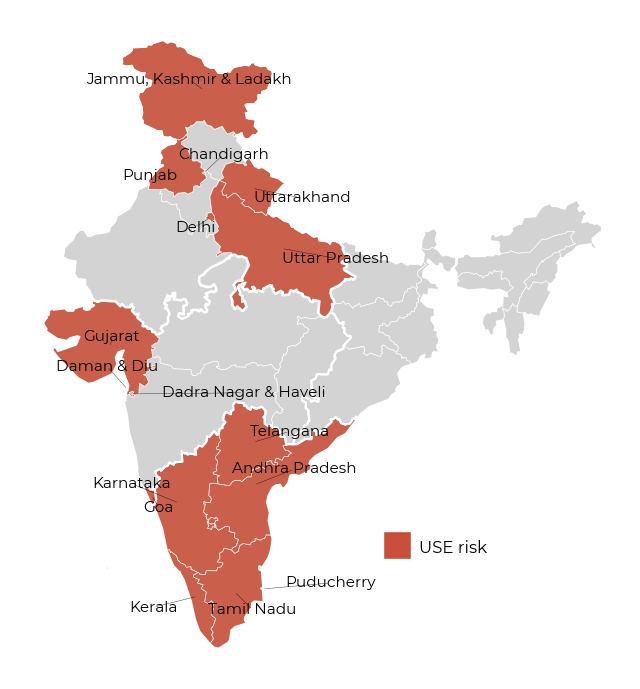

In [31]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 7.5))

# All states light grey

_india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')

# Violating states red with black border
df_.loc[df_['violation']].plot(ax=ax, 
                               color="#c94f39", 
                               edgecolor="white", 
                               alpha = 0.875,
                               lw = 0.5, 
                               zorder=2)

_nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_northeastern.plot(ax = ax, zorder =3 , color = 'None', lw = 1.5, edgecolor = 'white')
_western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

# Labels for violating states
df_["label_point"] = df_['geometry'].representative_point()

texts_ = []
for _, row in df_.loc[df_['violation']].iterrows():
    #state_name = row["load_zone_full"]
    #state_name = row["load_zone_abr"]
    state_name = row["load_zone"]

    state_name = state_name.replace("_", " ")
    state_name = state_name.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
    state_name = state_name.replace("Daman Diu", "Daman & Diu")
    state_name = state_name.replace("Dadra Nagar Haveli", "Dadra Nagar & Haveli")

    text = ax.text(row["label_point"].x,
                   row["label_point"].y,
                   state_name,
                   fontsize = 11,
                   ha="center",
                   va="center",
                   zorder = 15)
    
    texts_.append(text)

# Let adjustText move the labels to avoid overlap
adjust_text(texts_,
            ax = ax, 
            zorder = 13.5,
            expand_text=(1, 1),
            arrowprops=dict(arrowstyle="-", 
                            color="k", 
                            linewidth=0.25))

risk_handle = Line2D([0], [0],
                     marker="s",              # square marker
                     color="none",            # no line
                     markerfacecolor="#c94f39",
                     markersize=20,
                     markeredgecolor = 'w',
                     linestyle="None",
                     label="USE risk")

ax.legend(handles=[risk_handle], loc=(0.6, 0.175), frameon = False, fontsize = 12) 

ax.set_xticks([]) 
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(path_to_images + '/risk_map.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.tight_layout()
plt.show()

# States violating the CEA Standards

In [24]:
# --- Merge with metrics ---
df_ = pd.merge(_india, metrics_df, on='load_zone')
print(df_.shape)

df_ = pd.merge(df_, load_zones_, on='load_zone')
print(df_.columns)

df_['load_zone_full'] = [f"{lz} ({abr})" for lz, abr in zip(df_['load_zone'], df_['load_zone_abr'])]

# LOLP = 0.0274
# LOLE = 1.0

LOLP = 0.01
NENS = 0.001

# --- Flag violating states ---
df_['violation'] = (df_['LOLP (%)'] > LOLP) 
print(df_.loc[df_['violation'], ['load_zone', 'LOLP (%)', 'NENS (%)']])

(34, 12)
Index(['id', 'load_zone', 'geometry', 'iterations (W,H,A)', 'LOLH (hrs/yr)',
       'EUE (MWh/yr)', 'LOLE (days/yr)', 'LOLE (days/10yr)',
       'LOLP (fraction of hrs)', 'LOLP (%)', 'Annual Energy (MWh/yr)',
       'NENS (%)', 'state', 'load_zone_abr', 'rps_zone', 'region'],
      dtype='object')
             load_zone  LOLP (%)  NENS (%)
3           Chandigarh  0.022197  0.002164
5   Dadra_Nagar_Haveli  0.237189  0.088328
6            Daman_Diu  0.064054  0.028366
7                  Goa  0.083080  0.035359
8              Gujarat  0.064054  0.005091
13              Kerala  0.032344  0.012946
20               Delhi  0.024099  0.011402
21          Puducherry  0.019026  0.020145
22              Punjab  0.080543  0.031228
25          Tamil_Nadu  0.010147  0.003414
26           Telangana  0.013318  0.002684
28       Uttar_Pradesh  0.015855  0.004557
29         Uttarakhand  0.041223  0.006308
33       Jammu_Kashmir  0.026636  0.007371


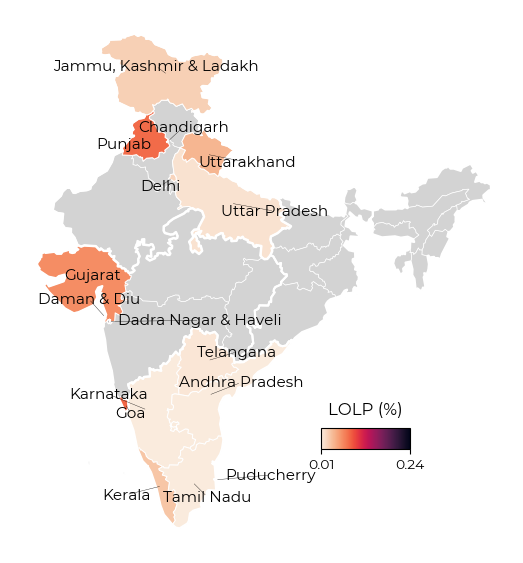

In [32]:
column = 'LOLP (%)' 

# --- Plot ---
fig, ax = plt.subplots(figsize=(6.5, 7.5))

# ---- Define a colormap ----
_cmap = sns.color_palette("rocket_r", as_cmap=True)
#_cmap = sns.dark_palette("#ef9226", reverse=True, as_cmap=True)

#_cmap = sns.blend_palette(["#6a96ac", "black"], as_cmap=True)
# ---- Create normalization based on your data ----
vmin = LOLP
vmax = df_[column].max()

_norm = colors.Normalize(vmin=vmin, vmax=vmax)

# All states light grey
_india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')

df_.loc[df_['violation']].plot(column=column,
                               cmap=_cmap,
                               linewidth=0.7,
                               edgecolor="white",
                               ax=ax,
                               norm=_norm)

_nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_northeastern.plot(ax = ax, zorder =3 , color = 'None', lw = 1.5, edgecolor = 'white')
_western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

# Labels for violating states
df_["label_point"] = df_['geometry'].representative_point()

texts_ = []
for _, row in df_.loc[df_['violation']].iterrows():
    #state_name = row["load_zone_full"]
    #state_name = row["load_zone_abr"]
    state_name = row["load_zone"]

    state_name = state_name.replace("_", " ")
    state_name = state_name.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
    state_name = state_name.replace("Daman Diu", "Daman & Diu")
    state_name = state_name.replace("Dadra Nagar Haveli", "Dadra Nagar & Haveli")

    text = ax.text(row["label_point"].x,
                   row["label_point"].y,
                   state_name,
                   fontsize = 11,
                   ha="center",
                   va="center",
                   zorder = 15)
    
    texts_.append(text)

# Let adjustText move the labels to avoid overlap
adjust_text(texts_,
            ax = ax, 
            zorder = 13.5,
            expand_text=(1, 1),
            arrowprops=dict(arrowstyle="-", 
                            color="k", 
                            linewidth=0.25))

# ---- Create colorbar ----
_sm = cm.ScalarMappable(cmap = _cmap, norm = _norm)
_sm.set_array([])     # required for older Matplotlib versions

cax = inset_axes(ax,
                 width="17.5%",     
                 height="3.75%",
                 loc="lower right",
                 borderpad=7.5)

_cbar = fig.colorbar(_sm, 
                     cax=cax, 
                     orientation="horizontal")

_cbar.ax.set_title('LOLP (%)', fontsize=12, pad=10)
_cbar.set_ticks([vmin, vmax])
_cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"], fontsize=10)  # format as you like

ax.set_xticks([]) 
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(path_to_images + '/LOLP_map.png', 
            bbox_inches = 'tight', 
            dpi         = 300)


# plt.tight_layout()
plt.show()

In [39]:
# --- Merge with metrics ---
df_ = pd.merge(_india, metrics_df, on='load_zone')
print(df_.shape)

df_ = pd.merge(df_, load_zones_, on='load_zone')
print(df_.columns)

df_['load_zone_full'] = [f"{lz} ({abr})" for lz, abr in zip(df_['load_zone'], df_['load_zone_abr'])]

# LOLP = 0.0274
# LOLE = 1.0

LOLP = 0.01
NENS = 0.001
print(df_['NENS (%)'].max())
# --- Flag violating states ---
df_['violation'] = (df_['NENS (%)'] > NENS) 
print(df_.loc[df_['violation'], ['load_zone', 'LOLP (%)', 'NENS (%)']])

(34, 12)
Index(['id', 'load_zone', 'geometry', 'iterations (W,H,A)', 'LOLH (hrs/yr)',
       'EUE (MWh/yr)', 'LOLE (days/yr)', 'LOLE (days/10yr)',
       'LOLP (fraction of hrs)', 'LOLP (%)', 'Annual Energy (MWh/yr)',
       'NENS (%)', 'state', 'load_zone_abr', 'rps_zone', 'region'],
      dtype='object')
0.08832763231721807
             load_zone  LOLP (%)  NENS (%)
3           Chandigarh  0.022197  0.002164
5   Dadra_Nagar_Haveli  0.237189  0.088328
6            Daman_Diu  0.064054  0.028366
7                  Goa  0.083080  0.035359
8              Gujarat  0.064054  0.005091
12           Karnataka  0.006976  0.005631
13              Kerala  0.032344  0.012946
20               Delhi  0.024099  0.011402
21          Puducherry  0.019026  0.020145
22              Punjab  0.080543  0.031228
25          Tamil_Nadu  0.010147  0.003414
26           Telangana  0.013318  0.002684
28       Uttar_Pradesh  0.015855  0.004557
29         Uttarakhand  0.041223  0.006308
32      Andhra_Pradesh  0.0

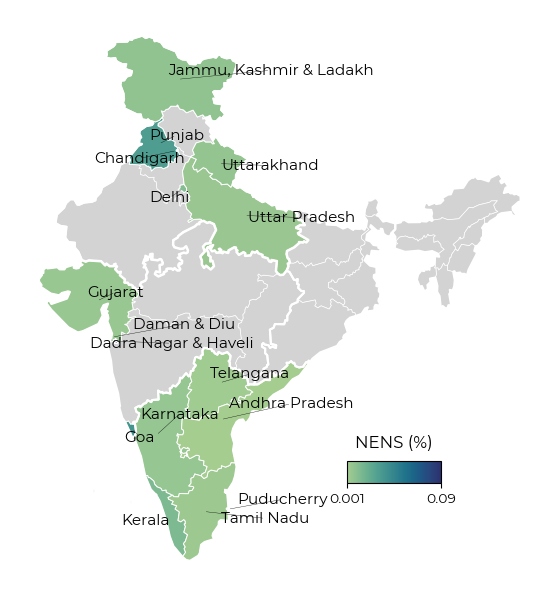

In [40]:
column = 'NENS (%)' 

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# ---- Define a colormap ----
_cmap = sns.color_palette("crest", as_cmap=True)
#_cmap = sns.dark_palette("#ef9226", reverse=True, as_cmap=True)

#_cmap = sns.blend_palette(["#6a96ac", "black"], as_cmap=True)
# ---- Create normalization based on your data ----
vmin = NENS
vmax = df_[column].max()

_norm = colors.Normalize(vmin=vmin, vmax=vmax)

# All states light grey
_india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')

df_.loc[df_['violation']].plot(column=column,
                               cmap=_cmap,
                               linewidth=0.7,
                               edgecolor="white",
                               ax=ax,
                               norm=_norm)

_nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_northeastern.plot(ax = ax, zorder =3 , color = 'None', lw = 1.5, edgecolor = 'white')
_western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

# Labels for violating states
df_["label_point"] = df_['geometry'].representative_point()

texts_ = []
for _, row in df_.loc[df_['violation']].iterrows():
    #state_name = row["load_zone_full"]
    #state_name = row["load_zone_abr"]
    state_name = row["load_zone"]

    state_name = state_name.replace("_", " ")
    state_name = state_name.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
    state_name = state_name.replace("Daman Diu", "Daman & Diu")
    state_name = state_name.replace("Dadra Nagar Haveli", "Dadra Nagar & Haveli")

    text = ax.text(row["label_point"].x,
                   row["label_point"].y,
                   state_name,
                   fontsize = 11,
                   ha="center",
                   va="center",
                   zorder = 15)
    
    texts_.append(text)

# Let adjustText move the labels to avoid overlap
adjust_text(texts_,
            ax = ax, 
            zorder = 13.5,
            expand_text=(1, 1),
            arrowprops=dict(arrowstyle="-", 
                            color="k", 
                            linewidth=0.25))

# ---- Create colorbar ----
_sm = cm.ScalarMappable(cmap = _cmap, norm = _norm)
_sm.set_array([])     # required for older Matplotlib versions

cax = inset_axes(ax,
                 width="17.5%",     
                 height="3.75%",
                 loc="lower right",
                 borderpad=7.5)

_cbar = fig.colorbar(_sm, 
                     cax = cax, 
                     orientation = "horizontal")

_cbar.ax.set_title(column, fontsize = 12, pad = 10)
_cbar.set_ticks([vmin, vmax])
_cbar.set_ticklabels([f"{vmin:.3f}", f"{vmax:.2f}"], fontsize = 10)  # format as you like

ax.set_xticks([]) 
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(path_to_images + '/NENS_map.png', 
            bbox_inches = 'tight', 
            dpi         = 300)


# plt.tight_layout()
plt.show()

In [16]:
# --- Merge with metrics ---
df_ = pd.merge(_india, metrics_df, on='load_zone')
print(df_.shape)

df_ = pd.merge(df_, load_zones_, on='load_zone')
print(df_.columns)

df_['load_zone_full'] = [f"{lz} ({abr})" for lz, abr in zip(df_['load_zone'], df_['load_zone_abr'])]

# LOLP = 0.0274
LOLE = .1

LOLP = 0.
NENS = 0.
# --- Flag violating states ---
df_['violation'] = (df_['LOLE (days/yr)'] > LOLE) 
print(df_.loc[df_['violation'], ['load_zone', 'LOLP (%)', 'NENS (%)', 'LOLE (days/yr)']])

(34, 12)
Index(['id', 'load_zone', 'geometry', 'iterations (W,H,A)', 'LOLH (hrs/yr)',
       'EUE (MWh/yr)', 'LOLE (days/yr)', 'LOLE (days/10yr)',
       'LOLP (fraction of hrs)', 'LOLP (%)', 'Annual Energy (MWh/yr)',
       'NENS (%)', 'state', 'load_zone_abr', 'rps_zone', 'region'],
      dtype='object')
             load_zone  LOLP (%)  NENS (%)  LOLE (days/yr)
3           Chandigarh  0.022197  0.002164        0.611111
5   Dadra_Nagar_Haveli  0.237189  0.088328        5.444444
6            Daman_Diu  0.064054  0.028366        2.000000
7                  Goa  0.083080  0.035359        1.777778
8              Gujarat  0.064054  0.005091        2.222222
13              Kerala  0.032344  0.012946        0.777778
15         Maharashtra  0.005708  0.000889        0.277778
20               Delhi  0.024099  0.011402        0.444444
21          Puducherry  0.019026  0.020145        0.444444
22              Punjab  0.080543  0.031228        1.166667
25          Tamil_Nadu  0.010147  0.003414 

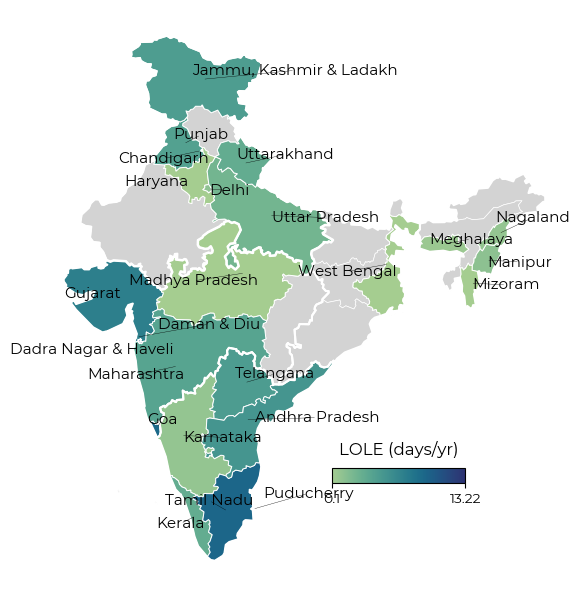

In [231]:
column = 'LOLE (days/yr)' 

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 7.5))

# ---- Define a colormap ----
_cmap = sns.color_palette("crest", as_cmap=True)
#_cmap = sns.dark_palette("#ef9226", reverse=True, as_cmap=True)

#_cmap = sns.blend_palette(["#6a96ac", "black"], as_cmap=True)
# ---- Create normalization based on your data ----
vmin = LOLE
vmax = df_[column].max()

_norm = colors.Normalize(vmin=vmin, vmax=vmax)

# All states light grey
_india.plot(ax = ax, zorder = 1, color = 'lightgray', lw = 0.5, edgecolor = 'white')

df_.loc[df_['violation']].plot(column=column,
                               cmap=_cmap,
                               linewidth=0.7,
                               edgecolor="white",
                               ax=ax,
                               norm=_norm)

_nothern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_northeastern.plot(ax = ax, zorder =3 , color = 'None', lw = 1.5, edgecolor = 'white')
_western.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_southern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')
_eastern.plot(ax = ax, zorder = 3, color = 'None', lw = 1.5, edgecolor = 'white')

# Labels for violating states
df_["label_point"] = df_['geometry'].representative_point()

texts_ = []
for _, row in df_.loc[df_['violation']].iterrows():
    #state_name = row["load_zone_full"]
    #state_name = row["load_zone_abr"]
    state_name = row["load_zone"]

    state_name = state_name.replace("_", " ")
    state_name = state_name.replace("Jammu Kashmir", "Jammu, Kashmir & Ladakh")
    state_name = state_name.replace("Daman Diu", "Daman & Diu")
    state_name = state_name.replace("Dadra Nagar Haveli", "Dadra Nagar & Haveli")

    text = ax.text(row["label_point"].x,
                   row["label_point"].y,
                   state_name,
                   fontsize = 11,
                   ha="center",
                   va="center",
                   zorder = 15)
    
    texts_.append(text)

# Let adjustText move the labels to avoid overlap
adjust_text(texts_,
            ax = ax, 
            zorder = 14,
            expand_text=(1, 1),
            arrowprops=dict(arrowstyle="-", 
                            color="k", 
                            linewidth=0.25))

# ---- Create colorbar ----
_sm = cm.ScalarMappable(cmap = _cmap, norm = _norm)
_sm.set_array([])     # required for older Matplotlib versions

cax = inset_axes(ax,
                 width="25%",     
                 height="2.5%",
                 loc="lower right",
                 borderpad=7.5)

_cbar = fig.colorbar(_sm, 
                     cax = cax, 
                     orientation = "horizontal")

_cbar.ax.set_title(column, fontsize = 12, pad = 10)
_cbar.set_ticks([vmin, vmax])
_cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.2f}"], fontsize = 10)  # format as you like

ax.set_xticks([]) 
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(path_to_images + '/LOLP_map.png', 
            bbox_inches = 'tight', 
            dpi         = 300)


# plt.tight_layout()
plt.show()